In [25]:
#Manejo de datos
import pandas as pd
import numpy as np

# Preprocesamiento y modelado
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge

# Visualización
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as sch
from sklearn.decomposition import PCA
import plotly.express as px
import plotly.io as pio


In [26]:
df_pt1 = pd.read_csv('../dataset/raw_world_bank_pt1.csv')
df_pt2 = pd.read_csv('../dataset/raw_world_bank_pt2.csv')
df_pt3 = pd.read_csv('../dataset/raw_world_bank_pt3.csv')
df_pt4 = pd.read_csv('../dataset/raw_world_bank_pt4.csv')
df_pt5 = pd.read_csv('../dataset/raw_world_bank_pt5.csv')
df_pt6 = pd.read_csv('../dataset/raw_world_bank_pt6.csv')
df_pt7 = pd.read_csv('../dataset/raw_world_bank_pt7.csv')
df_pt8 = pd.read_csv('../dataset/raw_world_bank_pt8.csv')
df_pt9 = pd.read_csv('../dataset/raw_world_bank_pt9.csv')
df_pt10 = pd.read_csv('../dataset/raw_world_bank_pt10.csv')

df_raw = pd.concat([df_pt1, df_pt2, df_pt3, df_pt4, df_pt5, df_pt6, df_pt7, df_pt8, df_pt9, df_pt10], ignore_index=True)


# Para comprobar que ha funcionado
df_raw.head()


,Country Name,Country Code,Series Name,Series Code,Time,Time Code,Value
0,Afghanistan,AFG,Multidimensional poverty headcount ratio (UNDP...,SI.POV.MPUN,1960.0,YR1960,NaN
1,Afghanistan,AFG,Multidimensional poverty headcount ratio (UNDP...,SI.POV.MPUN,1961.0,YR1961,NaN
2,Afghanistan,AFG,Multidimensional poverty headcount ratio (UNDP...,SI.POV.MPUN,1962.0,YR1962,NaN
3,Afghanistan,AFG,Multidimensional poverty headcount ratio (UNDP...,SI.POV.MPUN,1963.0,YR1963,NaN
4,Afghanistan,AFG,Multidimensional poverty headcount ratio (UNDP...,SI.POV.MPUN,1964.0,YR1964,NaN


In [27]:
df_raw.tail()

,Country Name,Country Code,Series Name,Series Code,Time,Time Code,Value
1591635,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1591636,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1591637,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1591638,Data from database: World Development Indicators,NaN,NaN,NaN,NaN,NaN,NaN
1591639,Last Updated: 07/13/2026,NaN,NaN,NaN,NaN,NaN,NaN


In [28]:
# 1. Transformar el formato 'Long' a 'Wide' (Matriz de Características)
df_wide = df_raw.pivot_table(
    index = ['Country Name', 'Country Code', 'Time'],
    columns = 'Series Code',
    values ='Value',
    aggfunc = 'first'# este argumento es necesario porque hay duplicados en el dataset, y no queremos que nos devuelva un error.
).reset_index()

# 2. Limpieza estética: eliminar el nombre de la jerarquía de columnas que deja pandas por defecto
df_wide.columns.name = None

# 3. Comprobación de la nueva arquitectura
print(f"Dimensiones de la nueva matriz : {df_wide.shape}")
df_wide.head()

Dimensiones de la nueva matriz : (17424, 94)


,Country Name,Country Code,Time,DT.DOD.DECT.GN.ZS,DT.DOD.DSTC.IR.ZS,DT.ODA.ODAT.GI.ZS,DT.ODA.ODAT.GN.ZS,DT.ODA.ODAT.XP.ZS,DT.TDS.DECT.GN.ZS,EG.ELC.ACCS.ZS,...,TX.VAL.MMTL.ZS.UN,TX.VAL.TRVL.ZS.WT,VC.BTL.DETH,VC.IDP.NWCV,VC.IDP.NWDS,VC.IHR.PSRC.P5,per_allsp.ben_q1_tot,per_allsp.cov_pop_tot,per_sa_allsa.adq_pop_tot,per_sa_allsa.cov_q1_tot
0,Afghanistan,AFG,1960.0,NaN,NaN,19.823067,3.129960,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,AFG,1961.0,NaN,NaN,38.052418,6.191071,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,AFG,1962.0,NaN,NaN,16.209565,3.035259,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,AFG,1963.0,NaN,NaN,34.378105,4.783043,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,AFG,1964.0,NaN,NaN,41.552982,5.661171,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [29]:
# 1. Definir las columnas de identificación que NO deben contar para borrar la fila
id_cols = ['Country Name', 'Country Code', 'Time']

# 2. Aislar dinámicamente las columnas de los indicadores (tus variables predictoras)
feature_cols = [col for col in df_wide.columns if col not in id_cols]

# 3. Eliminar filas donde TODAS las columnas de 'feature_cols' sean NaN
# El parámetro how='all' es la clave: solo borra si el 100% de las variables son nulas
df_base = df_wide.dropna(subset=feature_cols, how='all')

# 4. Calcular la volumetría y el balance de nulos tras la limpieza
total_filas = df_base.shape[0]
total_celdas = df_base[feature_cols].size
nulos_totales = df_base[feature_cols].isna().sum().sum()
no_nulos_totales = df_base[feature_cols].count().sum()
porcentaje_escasez = (nulos_totales / total_celdas) * 100

# 5. Imprimir el reporte del EDA (Análisis Exploratorio de Datos)
print("=== REPORTE DE INGESTA Y LIMPIEZA BÁSICA ===")
print(f"Filas retenidas (con al menos 1 dato): {total_filas}")
print(f"Valores VÁLIDOS (no nulos) totales:    {no_nulos_totales:,}")
print(f"Valores NULOS (NaN) restantes:         {nulos_totales:,}")
print(f"Escasez de datos global en la matriz:  {porcentaje_escasez:.2f}%")

=== REPORTE DE INGESTA Y LIMPIEZA BÁSICA ===
Filas retenidas (con al menos 1 dato): 17424
Valores VÁLIDOS (no nulos) totales:    529,946
Valores NULOS (NaN) restantes:         1,055,638
Escasez de datos global en la matriz:  66.58%


# Observaciones Iniciales

Tras la eliminación de las filas que no contenian ningún índice observamos que seguimos teniendo una gran cantidad de nulos, el siguiente paso es observar cómo se distribuye ese porcentaje de nulos entre los diversos índices para pensar mejor qué podría ser lo siguiente que hagamos.


In [30]:


# 1. Calcular las métricas absolutas por cada columna (excluyendo identificadores)
nulos_por_columna = df_base[feature_cols].isna().sum()
validos_por_columna = df_base[feature_cols].count()
total_filas = len(df_base)

# 2. Construir un DataFrame específico para la auditoría
auditoria_columnas = pd.DataFrame({
    'Valores_Validos' : validos_por_columna,
    'Valores_Nulos' : nulos_por_columna,
    'Porcentaje_Nulo (%)' : (nulos_por_columna / total_filas) * 100
})


# 3. Ordenar los indicadores de mayor a menor escasez de datos
auditoria_columnas = auditoria_columnas.sort_values(by='Porcentaje_Nulo (%)', ascending=False)


# 4. Redondear el porcentaje a dos decimales para mayor limpieza visual
auditoria_columnas['Porcentaje_Nulo (%)'] = auditoria_columnas['Porcentaje_Nulo (%)'].round(2)


# 5. Mostrar los resultados en consola (los peores y los mejores)
print("--- TOP 10 INDICADORES CON MÁS NULOS (Candidatos a poda) ---")
print(auditoria_columnas.head(10))

print("\n--- TOP 10 INDICADORES CON MÁS DATOS (Los más robustos) ---")
print(auditoria_columnas.tail(10))



--- TOP 10 INDICADORES CON MÁS NULOS (Candidatos a poda) ---
                          Valores_Validos  Valores_Nulos  Porcentaje_Nulo (%)
SG.TIM.UWRK.FE                         66          17358                99.62
SI.POV.MPUN                           109          17315                99.37
SG.VAW.REAS.ZS                        200          17224                98.85
SL.TLF.0714.ZS                        281          17143                98.39
IC.FRM.CRDC.FL.ZS                     324          17100                98.14
SE.LPV.PRIM                           382          17042                97.81
per_sa_allsa.adq_pop_tot              479          16945                97.25
IC.FRM.CMPU.ZS                        520          16904                97.02
IC.FRM.BRIB.ZS                        530          16894                96.96
IC.FRM.DURS                           534          16890                96.94

--- TOP 10 INDICADORES CON MÁS DATOS (Los más robustos) ---
                   V

In [31]:
# Exportar la tabla completa para analizarla en Excel o adjuntarla al TFG
auditoria_columnas.to_csv('../dataset/auditoria_variables_wdi.csv')

# Observaciones

Viendo con más detenimiento la distribución de nulos vemos cómo indices como los de pobreza multidimensional, las actitudes sobre violencia contra la mujes o la porporcione de trabajo no remunerado en mujeres superan un 95% de mujeres y que hasta 71 de los 91 índices superan un 50% de nulos

Por ello, es obvio que no podemos simplemente implementar de primeras este dataframe a un modelo ya que colapsaria y no sería demasiado fiables.

Para solventar esto, analizaremos qué opción nos viene mejor de primeras para obtener una mejor cantidad de datos, si recortar datos por años (ya que es entendible por diversas razones que en años de mayor antigueda hubiera menor recolecta de datos) o si es mejor primero eliminar directamente aquellos índices con mayor cantidad de nulos

# Implicaciones

El objetivo de todo esto es tratar de elegir si preferimos quedarnos con menor cantidad de datos pero de mayor calidad o si por otro lado nos es más rentable elegir quedarnos con una mayor cantidad de indices aunque eso quizá disminuya la calidad.

De este modo podremos obtener una base más sólida con la que trabajar antes de modelar o rellenar huecos faltantes con diversos métodos.

In [32]:
print("="*60)
print(" SIMULACIÓN DE ESTRATEGIAS DE REDUCCIÓN DE NULOS (TFG)")
print("="*60)

# ---------------------------------------------------------
# OPCIÓN 1: RECORTE TEMPORAL (Solo del año 2000 en adelante)
# ---------------------------------------------------------
print("\n[ OPCIÓN 1: RECORTE TEMPORAL (Año >= 2000) ]")
df_2000 = df_base[df_base['Time'] >= 2000].copy()

filas_2000 = df_2000.shape[0]
celdas_2000 = df_2000[feature_cols].size
nulos_2000 = df_2000[feature_cols].isna().sum().sum()
escasez_2000 = (nulos_2000 / celdas_2000) * 100

# Auditoría por columna en esta franja moderna
nulos_col_2000 = df_2000[feature_cols].isna().sum() / filas_2000 * 100
cols_mas_80_2000 = (nulos_col_2000 > 80).sum()
cols_mas_50_2000 = (nulos_col_2000 > 50).sum()

print(f"-> Años evaluados: 2000 hasta el presente")
print(f"-> Filas resultantes (país-año): {filas_2000}")
print(f"-> Escasez global de datos: {escasez_2000:.2f}% (Bajó desde 66.58%?)")
print(f"-> Variables que SIGUEN con > 80% nulos: {cols_mas_80_2000} (Antes eran 31)")
print(f"-> Variables que SIGUEN con > 50% nulos: {cols_mas_50_2000} (Antes eran 71)")


# ---------------------------------------------------------
# OPCIÓN 2: PODA DE VARIABLES (Sin importar el año, borrar >80% nulos)
# ---------------------------------------------------------
print("\n[ OPCIÓN 2: PODA ESTRICTA (Eliminar variables con > 80% nulos globales) ]")

# Calcular qué columnas superan el 80% de nulos en el dataset entero (desde 1960)
porc_nulos_orig = (df_base[feature_cols].isna().sum() / len(df_base)) * 100
cols_a_mantener_poda = porc_nulos_orig[porc_nulos_orig <= 80].index.tolist()

# Crear dataset simulado con esas columnas eliminadas
df_poda = df_base[id_cols + cols_a_mantener_poda].copy()

# Al borrar columnas, puede que filas enteras se queden vacías, las limpiamos:
df_poda = df_poda.dropna(subset=cols_a_mantener_poda, how='all')

filas_poda = df_poda.shape[0]
escasez_poda = (df_poda[cols_a_mantener_poda].isna().sum().sum() / df_poda[cols_a_mantener_poda].size) * 100

print(f"-> Indicadores eliminados de raíz: {len(feature_cols) - len(cols_a_mantener_poda)}")
print(f"-> Indicadores supervivientes: {len(cols_a_mantener_poda)} (de 91 originales)")
print(f"-> Filas retenidas (país-año): {filas_poda}")
print(f"-> Escasez global de datos: {escasez_poda:.2f}%")


# ---------------------------------------------------------
# OPCIÓN 3: ENFOQUE HÍBRIDO (El más común en Data Science)
# ---------------------------------------------------------
print("\n[ OPCIÓN 3: HÍBRIDA (Año >= 2000 + Poda de variables malas en esa franja) ]")

# Usar el dataset temporal post-2000 y ver qué columnas son malas *incluso* ahí
cols_mantener_hib = nulos_col_2000[nulos_col_2000 <= 60].index.tolist() # Somos más estrictos: exigimos máximo 60% nulos

df_hibrido = df_2000[id_cols + cols_mantener_hib].copy()
df_hibrido = df_hibrido.dropna(subset=cols_mantener_hib, how='all')

filas_hib = df_hibrido.shape[0]
escasez_hib = (df_hibrido[cols_mantener_hib].isna().sum().sum() / df_hibrido[cols_mantener_hib].size) * 100

print(f"-> Indicadores supervivientes: {len(cols_mantener_hib)} (de 91)")
print(f"-> Filas retenidas (país-año): {filas_hib}")
print(f"-> Escasez global combinada: {escasez_hib:.2f}%")
print("="*60)

 SIMULACIÓN DE ESTRATEGIAS DE REDUCCIÓN DE NULOS (TFG)

[ OPCIÓN 1: RECORTE TEMPORAL (Año >= 2000) ]
-> Años evaluados: 2000 hasta el presente
-> Filas resultantes (país-año): 6864
-> Escasez global de datos: 45.74% (Bajó desde 66.58%?)
-> Variables que SIGUEN con > 80% nulos: 20 (Antes eran 31)
-> Variables que SIGUEN con > 50% nulos: 36 (Antes eran 71)

[ OPCIÓN 2: PODA ESTRICTA (Eliminar variables con > 80% nulos globales) ]
-> Indicadores eliminados de raíz: 31
-> Indicadores supervivientes: 60 (de 91 originales)
-> Filas retenidas (país-año): 17424
-> Escasez global de datos: 53.23%

[ OPCIÓN 3: HÍBRIDA (Año >= 2000 + Poda de variables malas en esa franja) ]
-> Indicadores supervivientes: 59 (de 91)
-> Filas retenidas (país-año): 6864
-> Escasez global combinada: 25.93%


# Veredicto 🏆

Lo cierto es que tras observar ambas opciones (recorte temporal y recorte de índices) y añadir una híbrida. Como era de esperar, la opción híbrida es la que más reduce el porcentaje global de nulos a casi un 26% que, teniendo en cuenta que venimos de un 66'56% es un porentaje bastante más aceptable.

In [33]:
# 1. Filtro temporal: Conservar solo desde el año 2000
df_final = df_base[df_base['Time'] >= 2000].copy()

# 2. Calcular el porcentaje de nulos en esta franja moderna
nulos_pct = (df_final[feature_cols].isna().sum() / len(df_final)) * 100

# 3. Separar las columnas que sobreviven (<= 60% nulos) y las que caen (> 60%)
cols_mantener = nulos_pct[nulos_pct <= 60].index.tolist()
cols_eliminar = nulos_pct[nulos_pct > 60].index.tolist()

# 4. Aplicar la poda de variables y limpiar filas completamente vacías en el nuevo contexto
df_final = df_final[id_cols + cols_mantener].copy()
df_final = df_final.dropna(subset=cols_mantener, how='all')

# 5. Imprimir los resultados para la auditoría semántica
print("=== ❌ INDICADORES ELIMINADOS (Descartados por >60% nulos desde 2000) ===")
for i, col in enumerate(cols_eliminar, 1):
    print(f"{i}. {col} (Nulos: {nulos_pct[col]:.2f}%)")

print("\n=== ✅ INDICADORES SUPERVIVIENTES (El núcleo del modelo) ===")
for i, col in enumerate(cols_mantener, 1):
    print(f"{i}. {col} (Nulos: {nulos_pct[col]:.2f}%)")

print(f"\nResumen final: {len(cols_mantener)} mantenidos | {len(cols_eliminar)} eliminados.")
print(f"Dimensiones de la matriz lista para imputación: {df_final.shape}")

=== ❌ INDICADORES ELIMINADOS (Descartados por >60% nulos desde 2000) ===
1. DT.ODA.ODAT.XP.ZS (Nulos: 73.81%)
2. EN.POP.SLUM.UR.ZS (Nulos: 64.70%)
3. FB.AST.NPER.ZS (Nulos: 65.66%)
4. FX.OWN.TOTL.ZS (Nulos: 88.29%)
5. GC.DOD.TOTL.GD.ZS (Nulos: 81.75%)
6. GC.REV.SOCL.ZS (Nulos: 64.09%)
7. IC.FRM.BRIB.ZS (Nulos: 92.28%)
8. IC.FRM.CMPU.ZS (Nulos: 92.42%)
9. IC.FRM.CRDC.FL.ZS (Nulos: 95.28%)
10. IC.FRM.DURS (Nulos: 92.22%)
11. IQ.CPA.PROT.XQ (Nulos: 64.34%)
12. IQ.CPA.SOCI.XQ (Nulos: 64.29%)
13. IQ.CPA.TRAN.XQ (Nulos: 64.22%)
14. SE.ADT.LITR.ZS (Nulos: 73.00%)
15. SE.LPV.PRIM (Nulos: 94.43%)
16. SG.TIM.UWRK.FE (Nulos: 99.04%)
17. SG.VAW.REAS.ZS (Nulos: 97.10%)
18. SH_UHC_FH40_PUSHED (Nulos: 83.00%)
19. SI.POV.MPUN (Nulos: 98.41%)
20. SI.POV.NAHC (Nulos: 83.92%)
21. SI.POV.UMIC.GP (Nulos: 68.04%)
22. SI.RMT.COST.IB.ZS (Nulos: 88.64%)
23. SL.TLF.0714.ZS (Nulos: 96.11%)
24. SL.TLF.BASC.ZS (Nulos: 61.96%)
25. SM.POP.TOTL.ZS (Nulos: 77.01%)
26. VC.BTL.DETH (Nulos: 84.91%)
27. VC.IDP.NWCV (Nulos

In [34]:
# Cambia 'df' por el nombre real de tu variable si es diferente
print("=== 1. INFORMACIÓN GENERAL Y TIPOS DE DATOS ===")
df_final.info()

print("\n=== 2. VALORES NULOS (Top 15 columnas con más huecos) ===")
print(df_final.isnull().sum().sort_values(ascending=False).head(15))

print("\n=== 3. MUESTRA DE LAS PRIMERAS 3 FILAS ===")
try:
    display(df_final.head(3)) # Formato enriquecido en Jupyter
except:
    print(df_final.head(3))   # Alternativa en texto plano

=== 1. INFORMACIÓN GENERAL Y TIPOS DE DATOS ===
<class 'pandas.DataFrame'>
Index: 6864 entries, 40 to 17423
Data columns (total 62 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Country Name       6864 non-null   str    
 1   Country Code       6864 non-null   str    
 2   Time               6864 non-null   float64
 3   DT.DOD.DECT.GN.ZS  3215 non-null   float64
 4   DT.DOD.DSTC.IR.ZS  3370 non-null   float64
 5   DT.ODA.ODAT.GI.ZS  3630 non-null   float64
 6   DT.ODA.ODAT.GN.ZS  4324 non-null   float64
 7   DT.TDS.DECT.GN.ZS  3728 non-null   float64
 8   EG.ELC.ACCS.ZS     6525 non-null   float64
 9   ER.H2O.FWST.ZS     3953 non-null   float64
 10  FI.RES.TOTL.DT.ZS  3601 non-null   float64
 11  FI.RES.TOTL.MO     5273 non-null   float64
 12  FP.CPI.TOTL.ZG     5905 non-null   float64
 13  GC.TAX.TOTL.GD.ZS  3710 non-null   float64
 14  GC.XPN.INTP.RV.ZS  3755 non-null   float64
 15  GC.XPN.TRFT.ZS     3496 non-null   flo

,Country Name,Country Code,Time,DT.DOD.DECT.GN.ZS,DT.DOD.DSTC.IR.ZS,DT.ODA.ODAT.GI.ZS,DT.ODA.ODAT.GN.ZS,DT.TDS.DECT.GN.ZS,EG.ELC.ACCS.ZS,ER.H2O.FWST.ZS,...,SP.ADO.TFRT,SP.POP.0014.TO.ZS,SP.POP.65UP.TO.ZS,ST.INT.RCPT.XP.ZS,TM.VAL.FOOD.ZS.UN,TX.MNF.TECH.ZS.UN,TX.VAL.FUEL.ZS.UN,TX.VAL.MMTL.ZS.UN,TX.VAL.TRVL.ZS.WT,VC.IHR.PSRC.P5
40,Afghanistan,AFG,2000.0,NaN,NaN,NaN,3.987223,NaN,4.4,54.757019,...,154.310,50.024930,2.261970,NaN,NaN,0.0,NaN,NaN,NaN,NaN
41,Afghanistan,AFG,2001.0,NaN,NaN,NaN,14.529245,NaN,9.3,54.757019,...,152.471,50.168690,2.261948,NaN,NaN,0.0,NaN,NaN,NaN,NaN
42,Afghanistan,AFG,2002.0,NaN,NaN,NaN,31.473367,NaN,14.1,54.757019,...,150.161,50.237897,2.263974,NaN,NaN,0.0,NaN,NaN,NaN,NaN


# Siguientes pasos

A continuación, antes de seguir desarrollando el proyecto eligiendo un modelo debemos hacer lo siguiente.
1. Implementar Clustering para:
    
    - A. Agrupar variables y imputar usando las que estén más relacionadas por grupos en vez de todo en conjunto
    
    - B. Agrupar por Paises con imputación temporal y asó dividir mejor entre paises con diferentes niveles de vulnerabilidad para afianzar una mejor imputación de valores


<Figure size 1600x1400 with 0 Axes>

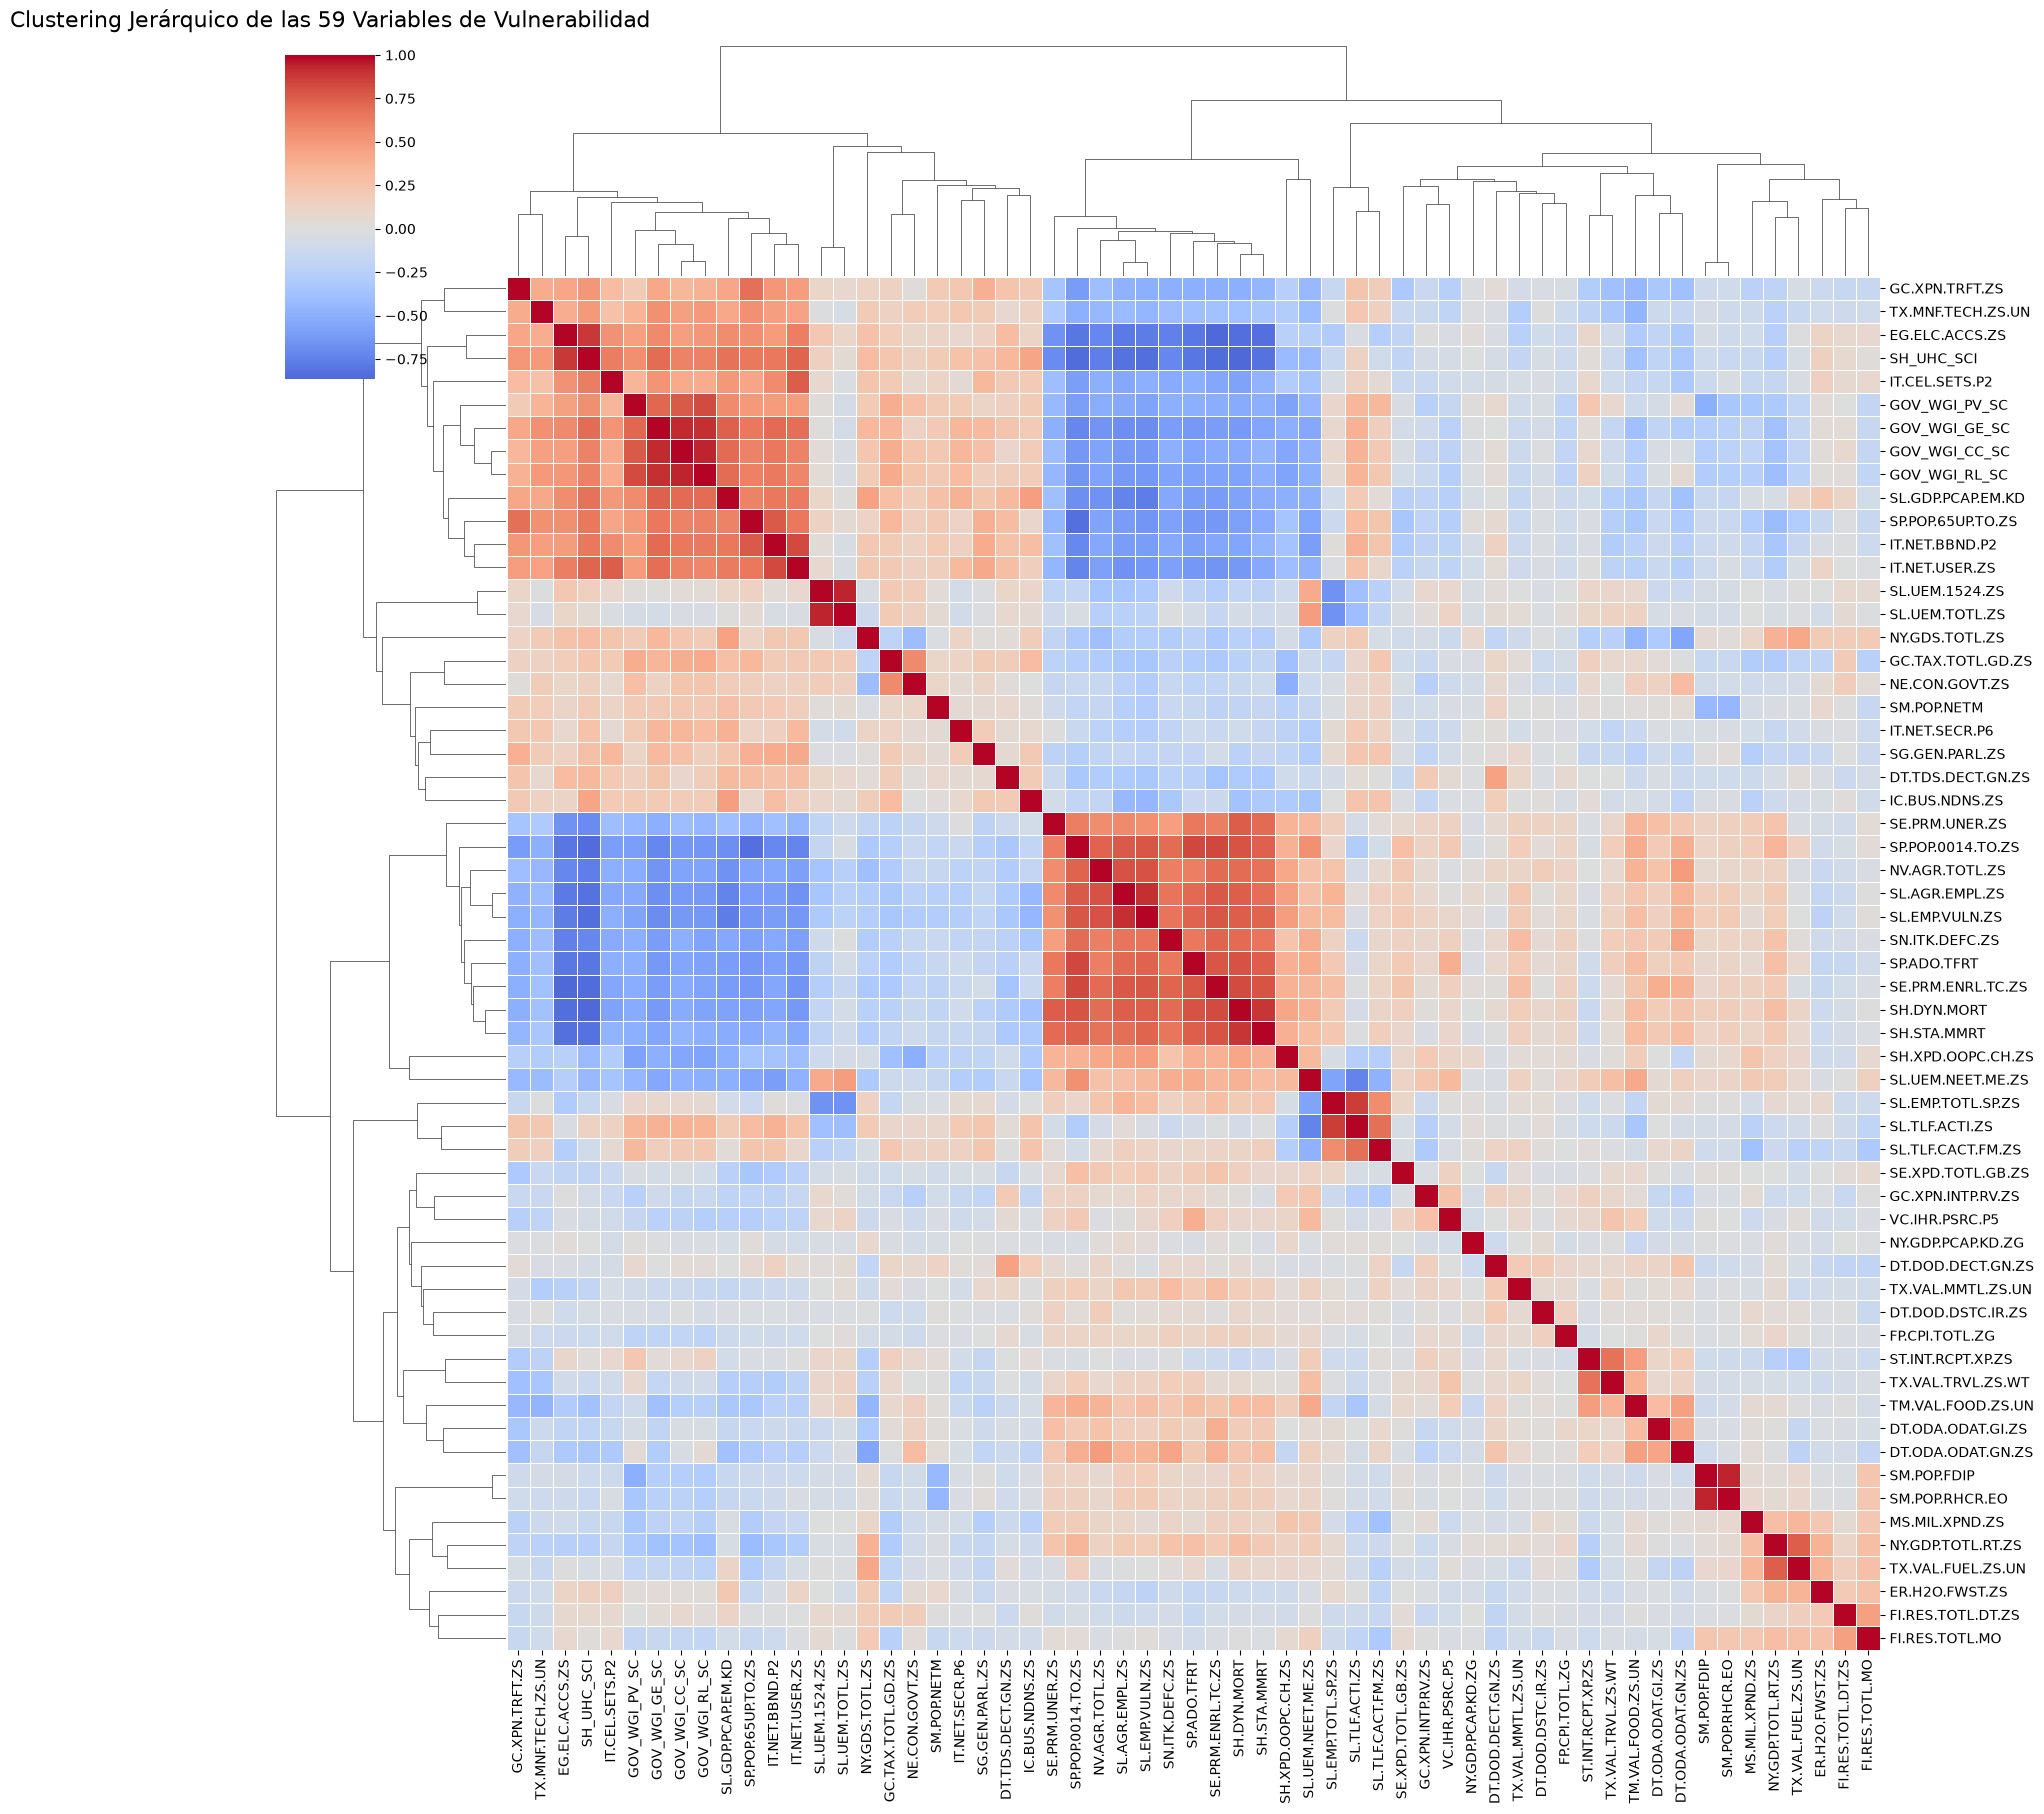

In [35]:


# 1. Calculamos la matriz de correlación (Pandas ignora los nulos automáticamente)
corr_matrix = df_final[cols_mantener].corr()

# 2. Configurar el tamaño del gráfico (lo hacemos grande porque son 59 variables)
plt.figure(figsize=(16, 14))

# 3. Crear el Clustermap
# Esto agrupa las variables que se comportan de forma similar a lo largo de los años y países
clustermap = sns.clustermap(
    corr_matrix, 
    cmap='coolwarm', 
    center=0, 
    annot=False,
    linewidths=.5,
    figsize=(18, 18),
    dendrogram_ratio=0.15
)

plt.title("Clustering Jerárquico de las 59 Variables de Vulnerabilidad", size=16, pad=20)
plt.show()

#### Pequeña trampa de EDA (Análisis exploratorio de datos)

Para el análisis de clustering de paises, ya que usaremos kmeans para dividir los grupos, deberemos rellener lso valores faltantes con las medianas. Lo cual si fuera el modelo final sería un error hacer, sin embargo como lo único que queremos ahora mismo es hacernos una idea general de las divisiones de los paises aceptaremos por lo pronto este margen de error.

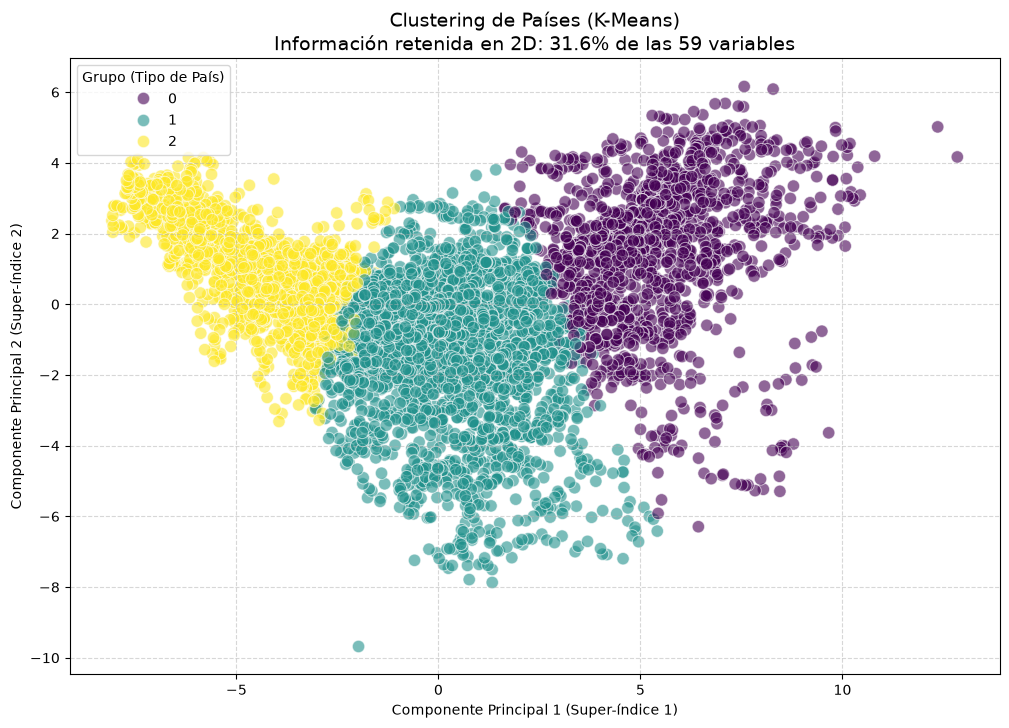

In [36]:


# 1. Preparar los datos numéricos (solo las 59 variables)
X = df_final[cols_mantener].copy()

# 2. Imputación temporal rápida (rellenar nulos con la mediana global de cada columna)
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)

# 3. Escalado de datos (Vital para el clustering: que el PIB no aplaste a los % de internet)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# 4. Aplicar K-Means (Vamos a forzar 3 grupos para empezar: Ej. Alta, Media y Baja vulnerabilidad)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# 5. Reducción de dimensionalidad a 2D solo para poder graficar (PCA)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Calcular cuánta información (varianza) retienen estos 2 componentes
var_explicada = pca.explained_variance_ratio_.sum() * 100

# 6. Crear un DataFrame para visualizar
df_vis = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'Cluster': clusters
})

# 7. Graficar el resultado
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df_vis, 
    x='PC1', 
    y='PC2', 
    hue='Cluster', 
    palette='viridis', 
    alpha=0.6,
    s=80
)
plt.title(f"Clustering de Países (K-Means)\nInformación retenida en 2D: {var_explicada:.1f}% de las 59 variables", size=14)
plt.xlabel("Componente Principal 1 (Super-índice 1)")
plt.ylabel("Componente Principal 2 (Super-índice 2)")
plt.legend(title="Grupo (Tipo de País)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

#### Perdida de información

Al reducir a 2D toda la explicación perdemos gran cantidad de información como se puede ver (31'6% de las 59 variables), por ello procederemo a implementar una graficación en 3D de los super Indices para tratar de retener mayor información y poder dividir mejor

In [37]:
# Opción 1: Visualización interactiva con Plotly (Renderizado en Navegador)



# 1. Aplicar PCA pero ahora pidiendo 3 dimensiones
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_scaled)

# 2. Calcular cuánta información retenemos ahora
var_explicada_3d = pca_3d.explained_variance_ratio_.sum() * 100
print(f"Información retenida en 3D: {var_explicada_3d:.1f}% (antes era 31.6%)")

# 3. Preparar el DataFrame para Plotly
df_vis_3d = pd.DataFrame({
    'PC1': X_pca_3d[:, 0],
    'PC2': X_pca_3d[:, 1],
    'PC3': X_pca_3d[:, 2],
    'Cluster': clusters.astype(str) # Lo pasamos a texto para colores categóricos
})

# 4. Crear el gráfico interactivo
fig = px.scatter_3d(
    df_vis_3d, 
    x='PC1', 
    y='PC2', 
    z='PC3',
    color='Cluster',
    title=f"Clustering de Países (3D) - Varianza Retenida: {var_explicada_3d:.1f}%",
    opacity=0.6,
    color_discrete_sequence=px.colors.qualitative.Vivid
)

# 5. Ajustar un poco el tamaño para que se vea mejor
fig.update_layout(margin=dict(l=0, r=0, b=0, t=40))

# 6. ESTA ES LA CLAVE: Forzamos a que se abra en tu navegador web
pio.renderers.default = "browser"

# 7. Mostrar el gráfico (se abrirá en Chrome, Edge, Safari, etc.)
fig.show()

Información retenida en 3D: 37.3% (antes era 31.6%)


### 📝 Conclusiones del Análisis previo de Reducción de Dimensionalidad (PCA) y Clustering 3D

Tras aplicar K-Means ($k=3$) y proyectar los resultados en un espacio tridimensional mediante Análisis de Componentes Principales (PCA), extraemos las siguientes conclusiones sobre la estructura subyacente del dataset:

*   **Dominancia del Primer Componente (Eje Macro-Estructural):** 
    La segmentación de los clústeres se produce de forma casi ortogonal a lo largo del **Componente Principal 1 (PC1)**. Esto confirma la hipótesis del análisis exploratorio inicial: existe un gran eje latente (probablemente "Desarrollo vs. Vulnerabilidad") que condensa la mayor parte del peso explicativo y diferencia radicalmente a los países en extremos opuestos.

*   **Transición Continua (Ausencia de Fronteras Duras):** 
    Al rotar el espacio 3D, se observa un solapamiento evidente en las fronteras de los tres grupos (Alta, Media y Baja vulnerabilidad). Esto refleja fielmente la naturaleza de las ciencias sociales: el progreso macroeconómico y social es un continuo progresivo, no un fenómeno de saltos discretos o islas aisladas.

*   **Alta Complejidad Dimensional (Alerta de Varianza):** 
    La proyección en 3D logra retener únicamente un **37.3% de la varianza explicada** (frente al 31.6% del modelo 2D). Esto implica que cerca del 63% de la información contenida en las 59 variables originales reside en dimensiones superiores (hiperespacio). El dataset posee una estructura muy compleja y llena de matices que no pueden simplificarse visualmente.

*   **Justificación de la Estrategia de Imputación:** 
    Dado que existen perfiles de países tan diferenciados y una alta dimensionalidad subyacente, **se descarta definitivamente la imputación global por medidas de tendencia central (media/mediana)**. Introducir ruido estático destruiría esta estructura de clústeres. Es imperativo aplicar técnicas multivariantes que respeten la covarianza de los datos.

### Siguientes pasos:
*   Proceder a la imputación definitiva de los valores nulos (25%) utilizando algoritmos de Machine Learning, como `IterativeImputer` (MICE), para modelar cada variable en función del resto de características del país.

In [38]:
# 1. Separar identificadores del contexto
cols_id = ['Country Name', 'Country Code', 'Time']
df_ids = df_final[cols_id].copy()
df_features = df_final.drop(columns=cols_id)

print(f"Total de nulos antes de MICE (¡debe ser mayor a 0!): {df_features.isnull().sum().sum()}")

# 2. Guardar los límites reales (mínimos y máximos históricos) ANTES de imputar
# Esto es vital porque si lo hacemos después, los límites incluirán las aberraciones matemáticas
limites_min = df_features.min()
limites_max = df_features.max()

# 3. Configurar y entrenar MICE
imputer_mice = IterativeImputer(
    estimator=BayesianRidge(),
    max_iter=10,        
    random_state=42,    
    tol=1e-3,           
    verbose=2           
)

print("\nIniciando imputación con MICE...")
features_imputed_array = imputer_mice.fit_transform(df_features)

# 4. Reconstruir el DataFrame de características
df_features_imputed = pd.DataFrame(
    features_imputed_array, 
    columns=df_features.columns, 
    index=df_features.index 
)

# 5. APLICAR CLIPPING: Recortar los valores disparatados
for col in df_features.columns:
    df_features_imputed[col] = df_features_imputed[col].clip(
        lower=limites_min[col], 
        upper=limites_max[col]
    )

# 6. Unir los identificadores con los datos limpios y recortados
df_final_v2 = pd.concat([df_ids, df_features_imputed], axis=1)

print(f"\nTotal de nulos en el dataset final: {df_final_v2.isnull().sum().sum()}")
print("¡Imputación Fase 1 + Clipping completada con éxito!")

# Verificamos si los valores negativos extremos han desaparecido
display(df_final_v2.head(3))

Total de nulos antes de MICE (¡debe ser mayor a 0!): 105006

Iniciando imputación con MICE...
[IterativeImputer] Completing matrix with shape (6864, 59)
[IterativeImputer] Ending imputation round 1/10, elapsed time 1.98
[IterativeImputer] Change: 31394712.25503454, scaled tolerance: 123209.473 
[IterativeImputer] Ending imputation round 2/10, elapsed time 3.38
[IterativeImputer] Change: 5113659.645552106, scaled tolerance: 123209.473 
[IterativeImputer] Ending imputation round 3/10, elapsed time 4.71
[IterativeImputer] Change: 1830313.8762280138, scaled tolerance: 123209.473 
[IterativeImputer] Ending imputation round 4/10, elapsed time 5.98
[IterativeImputer] Change: 694830.1926020441, scaled tolerance: 123209.473 
[IterativeImputer] Ending imputation round 5/10, elapsed time 7.28
[IterativeImputer] Change: 288122.4994961103, scaled tolerance: 123209.473 
[IterativeImputer] Ending imputation round 6/10, elapsed time 8.56
[IterativeImputer] Change: 227727.09225927416, scaled tolerance:

c:\Users\javie\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\impute\_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


,Country Name,Country Code,Time,DT.DOD.DECT.GN.ZS,DT.DOD.DSTC.IR.ZS,DT.ODA.ODAT.GI.ZS,DT.ODA.ODAT.GN.ZS,DT.TDS.DECT.GN.ZS,EG.ELC.ACCS.ZS,ER.H2O.FWST.ZS,...,SP.ADO.TFRT,SP.POP.0014.TO.ZS,SP.POP.65UP.TO.ZS,ST.INT.RCPT.XP.ZS,TM.VAL.FOOD.ZS.UN,TX.MNF.TECH.ZS.UN,TX.VAL.FUEL.ZS.UN,TX.VAL.MMTL.ZS.UN,TX.VAL.TRVL.ZS.WT,VC.IHR.PSRC.P5
40,Afghanistan,AFG,2000.0,1.154216,0.0,78.487330,3.987223,0.000457,4.4,54.757019,...,154.310,50.024930,2.261970,5.985081,21.400802,0.0,46.620331,16.786267,37.662073,12.283926
41,Afghanistan,AFG,2001.0,8.576966,0.0,118.056860,14.529245,0.162370,9.3,54.757019,...,152.471,50.168690,2.261948,17.349648,23.121972,0.0,16.551677,20.528936,43.817420,10.845033
42,Afghanistan,AFG,2002.0,1.154216,0.0,227.585737,31.473367,0.000457,14.1,54.757019,...,150.161,50.237897,2.263974,28.425460,29.369013,0.0,0.000000,15.275440,50.197621,9.837658


In [39]:
df_final_v2.info()

<class 'pandas.DataFrame'>
Index: 6864 entries, 40 to 17423
Data columns (total 62 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Country Name       6864 non-null   str    
 1   Country Code       6864 non-null   str    
 2   Time               6864 non-null   float64
 3   DT.DOD.DECT.GN.ZS  6864 non-null   float64
 4   DT.DOD.DSTC.IR.ZS  6864 non-null   float64
 5   DT.ODA.ODAT.GI.ZS  6864 non-null   float64
 6   DT.ODA.ODAT.GN.ZS  6864 non-null   float64
 7   DT.TDS.DECT.GN.ZS  6864 non-null   float64
 8   EG.ELC.ACCS.ZS     6864 non-null   float64
 9   ER.H2O.FWST.ZS     6864 non-null   float64
 10  FI.RES.TOTL.DT.ZS  6864 non-null   float64
 11  FI.RES.TOTL.MO     6864 non-null   float64
 12  FP.CPI.TOTL.ZG     6864 non-null   float64
 13  GC.TAX.TOTL.GD.ZS  6864 non-null   float64
 14  GC.XPN.INTP.RV.ZS  6864 non-null   float64
 15  GC.XPN.TRFT.ZS     6864 non-null   float64
 16  GOV_WGI_CC_SC      6864 non-null   flo

In [40]:


# 1. Copiamos el dataset para trabajar seguros
df_model = df_final_v2.copy()

# 2. Invertimos la variable de Gobernanza 
# (Multiplicamos por -1 para que un valor alto signifique alta vulnerabilidad)
df_model['GOV_WGI_PV_SC_inv'] = df_model['GOV_WGI_PV_SC'] * -1

# 3. Definimos las columnas que componen nuestro índice
cols_indice = [
    'SN.ITK.DEFC.ZS',      # Desnutrición
    'VC.IHR.PSRC.P5',      # Homicidios
    'SL.UEM.NEET.ME.ZS',   # Ninis
    'SE.PRM.UNER.ZS',      # Abandono escolar
    'GOV_WGI_PV_SC_inv'    # Gobernanza invertida
]

# 4. Estandarizamos (StandardScaler aplica Media = 0, Desviación Típica = 1)
scaler = StandardScaler()
scaled_values = scaler.fit_transform(df_model[cols_indice])
df_scaled = pd.DataFrame(scaled_values, columns=cols_indice)

# 5. Calculamos el índice (Media ponderada)
# Por defecto, .mean() da a todas el mismo peso (20%). 
df_model['Indice_Z'] = df_scaled.mean(axis=1)

# 6. Re-escalado de 0 a 100 para interpretación humana (MinMaxScaler lógico)
min_val = df_model['Indice_Z'].min()
max_val = df_model['Indice_Z'].max()

df_model['Target_Vulnerabilidad_100'] = ((df_model['Indice_Z'] - min_val) / (max_val - min_val)) * 100

# Eliminamos la columna Z temporal para no ensuciar
df_model = df_model.drop(columns=['Indice_Z'])

# Echamos un vistazo a los países más vulnerables vs los menos según nuestro nuevo índice
print("TOP 5 PAÍSES MÁS VULNERABLES (100 = Peor):")
print(df_model[['Country Name', 'Time', 'Target_Vulnerabilidad_100']].sort_values(by='Target_Vulnerabilidad_100', ascending=False).head())

print("\nTOP 5 PAÍSES MENOS VULNERABLES (0 = Mejor):")
print(df_model[['Country Name', 'Time', 'Target_Vulnerabilidad_100']].sort_values(by='Target_Vulnerabilidad_100', ascending=True).head())

TOP 5 PAÍSES MÁS VULNERABLES (100 = Peor):
                    Country Name    Time  Target_Vulnerabilidad_100
183   Africa Western and Central  2011.0                 100.000000
5736                     Georgia  2020.0                  96.467983
1311                    Barbados  2017.0                  94.806811
5737                     Georgia  2021.0                  93.275068
5735                     Georgia  2019.0                  91.157197

TOP 5 PAÍSES MENOS VULNERABLES (0 = Mejor):
                        Country Name    Time  Target_Vulnerabilidad_100
2834  Central Europe and the Baltics  2022.0                   0.000000
4472                Egypt, Arab Rep.  2010.0                   0.484662
3099                           China  2023.0                   0.682926
6060                       Greenland  2014.0                   0.686547
6058                       Greenland  2012.0                   0.721295


In [41]:
# 1. Copiamos el dataset para trabajar seguros
df_model_v2 = df_final_v2.copy()

# 2. Invertimos la variable de Gobernanza 
df_model_v2['GOV_WGI_PV_SC_inv'] = df_model_v2['GOV_WGI_PV_SC'] * -1

# 3. Definimos las columnas que componen nuestro índice
cols_indice = [
    'SN.ITK.DEFC.ZS',      # Desnutrición
    'VC.IHR.PSRC.P5',      # Homicidios
    'SL.UEM.NEET.ME.ZS',   # Ninis
    'SE.PRM.UNER.ZS',      # Abandono escolar
    'GOV_WGI_PV_SC_inv'    # Gobernanza invertida
]

# 4. Estandarizamos 
scaler = StandardScaler()
scaled_values = scaler.fit_transform(df_model_v2[cols_indice])
df_scaled = pd.DataFrame(scaled_values, columns=cols_indice)

# ==========================================
# CÁLCULO 1: MEDIA SIMPLE
# ==========================================
indice_media = df_scaled.mean(axis=1)
min_media = indice_media.min()
max_media = indice_media.max()
df_model_v2['Target_Vulnerabilidad_100'] = ((indice_media - min_media) / (max_media - min_media)) * 100

# ==========================================
# CÁLCULO 2: PCA
# ==========================================
pca = PCA(n_components=1)
pca_result = pca.fit_transform(df_scaled)
pesos_pca = pca.components_[0]

# Inversión lógica para el PCA
if np.sum(pesos_pca) < 0:
    pesos_pca = pesos_pca * -1
    pca_result = pca_result * -1

print("PESOS AUTOMÁTICOS ASIGNADOS POR EL PCA:\n" + "-"*40)
suma_absoluta = sum(abs(pesos_pca))
for col, peso in zip(cols_indice, pesos_pca):
    peso_porcentaje = (abs(peso) / suma_absoluta) * 100
    print(f"{col}: {peso_porcentaje:.1f}%")

df_model_v2['Indice_PCA_Raw'] = pca_result
min_pca = df_model_v2['Indice_PCA_Raw'].min()
max_pca = df_model_v2['Indice_PCA_Raw'].max()
df_model_v2['Target_PCA_100'] = ((df_model_v2['Indice_PCA_Raw'] - min_pca) / (max_pca - min_pca)) * 100
df_model_v2 = df_model_v2.drop(columns=['Indice_PCA_Raw'])

# ==========================================
# 6. COMPARATIVA FINAL
# ==========================================
print("\nCOMPARATIVA DE ÍNDICES (Media Simple vs PCA):")
print(df_model_v2[['Country Name', 'Time', 'Target_Vulnerabilidad_100', 'Target_PCA_100']].head())

PESOS AUTOMÁTICOS ASIGNADOS POR EL PCA:
----------------------------------------
SN.ITK.DEFC.ZS: 22.5%
VC.IHR.PSRC.P5: 11.6%
SL.UEM.NEET.ME.ZS: 19.5%
SE.PRM.UNER.ZS: 23.5%
GOV_WGI_PV_SC_inv: 22.8%

COMPARATIVA DE ÍNDICES (Media Simple vs PCA):
   Country Name    Time  Target_Vulnerabilidad_100  Target_PCA_100
40  Afghanistan  2000.0                  33.811564       69.507546
41  Afghanistan  2001.0                  34.851918       75.908934
42  Afghanistan  2002.0                  34.993284       69.280180
43  Afghanistan  2003.0                  36.389428       66.519716
44  Afghanistan  2004.0                  36.696306       61.391647


In [44]:
# ==========================================
# SEPARACIÓN Y AISLAMIENTO (Evitando Data Leakage)
# ==========================================

# 1. Definimos nuestra variable objetivo (y)
y = df_model_v2['Target_PCA_100']

# 2. Listamos todas las columnas que NO deben entrar en la matriz predictora
columnas_a_excluir = [
    
    
    # Targets (Lo que queremos predecir)
    'Target_Vulnerabilidad_100', 
    'Target_PCA_100', 
    
    # Variables originales que componen el Target (Para evitar Data Leakage)
    'SN.ITK.DEFC.ZS', 
    'VC.IHR.PSRC.P5', 
    'SL.UEM.NEET.ME.ZS', 
    'SE.PRM.UNER.ZS', 
    'GOV_WGI_PV_SC',       # Gobernanza original
    'GOV_WGI_PV_SC_inv'    # Gobernanza invertida
]

# 3. Creamos la matriz de características (X) eliminando esas columnas
X = df_model_v2.drop(columns=columnas_a_excluir)

# 4. Comprobación de auditoría
print("=== AUDITORÍA DE DIMENSIONES ===")
print(f"Dimensiones de la matriz predictora (X): {X.shape}")
print(f"Dimensiones de la variable objetivo (y): {y.shape}")

print("\n=== MUESTRA DE VARIABLES PREDICTORAS (X) ===")
display(X.head())

=== AUDITORÍA DE DIMENSIONES ===
Dimensiones de la matriz predictora (X): (6864, 57)
Dimensiones de la variable objetivo (y): (6864,)

=== MUESTRA DE VARIABLES PREDICTORAS (X) ===


,Country Name,Country Code,Time,DT.DOD.DECT.GN.ZS,DT.DOD.DSTC.IR.ZS,DT.ODA.ODAT.GI.ZS,DT.ODA.ODAT.GN.ZS,DT.TDS.DECT.GN.ZS,EG.ELC.ACCS.ZS,ER.H2O.FWST.ZS,...,SM.POP.RHCR.EO,SP.ADO.TFRT,SP.POP.0014.TO.ZS,SP.POP.65UP.TO.ZS,ST.INT.RCPT.XP.ZS,TM.VAL.FOOD.ZS.UN,TX.MNF.TECH.ZS.UN,TX.VAL.FUEL.ZS.UN,TX.VAL.MMTL.ZS.UN,TX.VAL.TRVL.ZS.WT
40,Afghanistan,AFG,2000.0,1.154216,0.0,78.487330,3.987223,0.000457,4.4,54.757019,...,3587327.0,154.310,50.024930,2.261970,5.985081,21.400802,0.0,46.620331,16.786267,37.662073
41,Afghanistan,AFG,2001.0,8.576966,0.0,118.056860,14.529245,0.162370,9.3,54.757019,...,3809763.0,152.471,50.168690,2.261948,17.349648,23.121972,0.0,16.551677,20.528936,43.817420
42,Afghanistan,AFG,2002.0,1.154216,0.0,227.585737,31.473367,0.000457,14.1,54.757019,...,2510294.0,150.161,50.237897,2.263974,28.425460,29.369013,0.0,0.000000,15.275440,50.197621
43,Afghanistan,AFG,2003.0,26.894479,0.0,237.673492,33.571025,0.000457,19.0,54.757019,...,2136039.0,143.750,50.240291,2.266753,28.847829,32.305702,0.0,0.000000,13.851712,48.170319
44,Afghanistan,AFG,2004.0,56.055661,0.0,255.676742,42.870022,1.114015,23.8,54.757019,...,2414460.0,136.930,50.176915,2.268647,33.117404,32.162954,0.0,0.000000,20.242826,53.467880


In [45]:
y.to_csv('../dataset/y_vulnerabilidad.csv', index=False)
X.to_csv('../dataset/X_vulnerabilidad_info.csv', index=False)